# Notebook 02 — Limpieza y Preprocesamiento

Partiendo de los hallazgos del EDA, limpio el dataset y lo preparo
para entrenar modelos. El **preprocesamiento** es la transformacion de datos crudos
en datos que los algoritmos de machine learning pueden usar correctamente.

**Lo que hago aqui:**
- Elimino duplicados por track_id
- Filtro canciones con popularidad < 10
- Creo features nuevas (duration_min)
- Hago el train/test split y lo guardo en disco
- Verifico que el split es correcto con visualizaciones


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'white',
                     'axes.spines.top':False,'axes.spines.right':False})
RED, GRAY, BLUE = '#ff2a36', '#cccccc', '#2980b9'

import os
os.makedirs('src/data', exist_ok=True)
os.makedirs('src/data/processed', exist_ok=True)
os.makedirs('resources/img', exist_ok=True)
print('Librerias cargadas.')

Librerias cargadas.


## I. Carga del dataset raw


In [2]:
df = pd.read_csv('/Users/andoni/Documents/DS BOOTCAMP/Data Science/ONLINE_DS_THEBRIDGE_Andoni/Módulo 3/Proyecto ML /sound-dna/src/data/raw/spotify_tracks.csv')
print(f'Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')

Dataset cargado: 114,000 filas x 21 columnas


## II. Eliminacion de duplicados

El dataset contiene canciones repetidas porque una misma cancion
puede pertenecer a varios generos a la vez.

Si no los elimino antes del split, la misma cancion podria estar
tanto en train como en test, y las metricas quedarian infladas artificialmente —
el modelo habia 'visto' esa cancion durante el entrenamiento.

Me quedo con la primera aparicion de cada track_id.


Antes:    114,000 filas
Despues:  89,741 filas
Eliminados: 24,259 duplicados (21.3%)


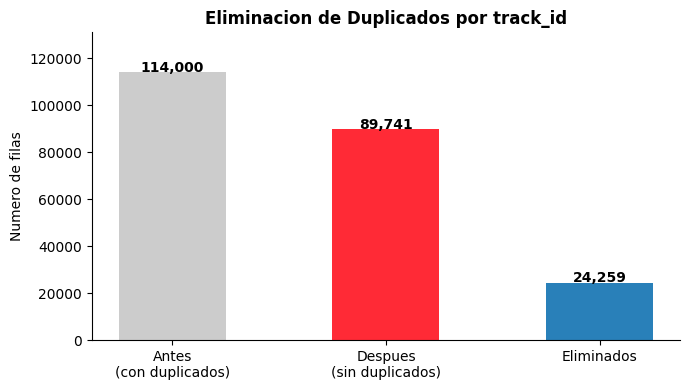

In [3]:
n_antes = len(df)

if 'track_id' in df.columns:
    df_clean = df.drop_duplicates(subset='track_id', keep='first').reset_index(drop=True)
else:
    df_clean = df.copy()
    print('Columna track_id no encontrada — no se eliminan duplicados por id.')

n_despues = len(df_clean)
n_eliminados = n_antes - n_despues

print(f'Antes:    {n_antes:,} filas')
print(f'Despues:  {n_despues:,} filas')
print(f'Eliminados: {n_eliminados:,} duplicados ({n_eliminados/n_antes*100:.1f}%)')

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['Antes\n(con duplicados)', 'Despues\n(sin duplicados)', 'Eliminados'],
              [n_antes, n_despues, n_eliminados],
              color=[GRAY, RED, BLUE], edgecolor='none', width=0.5)
for bar, val in zip(bars, [n_antes, n_despues, n_eliminados]):
    ax.text(bar.get_x()+bar.get_width()/2, val+300,
            f'{val:,}', ha='center', fontweight='bold', fontsize=10)
ax.set_ylabel('Numero de filas')
ax.set_title('Eliminacion de Duplicados por track_id', fontweight='bold')
ax.set_ylim(0, n_antes * 1.15)
plt.tight_layout()
plt.savefig('resources/img/prep_duplicados.png', dpi=150, bbox_inches='tight')
plt.show()

## III. Filtrado de canciones con popularidad muy baja

El dataset tiene un pico enorme de canciones con popularidad 0 o muy cercana a 0.
Estas canciones son basicamente invisibles en Spotify — nadie las escucha.
Son 'ruido' para el modelo: no representan patrones reales de exito o fracaso.

Elimino las que tienen popularidad < 10 (aproximadamente el 20% del dataset).


Antes del filtro:  89,741 canciones
Despues del filtro:75,875 canciones
Filtradas:         13,866 (15.5%)


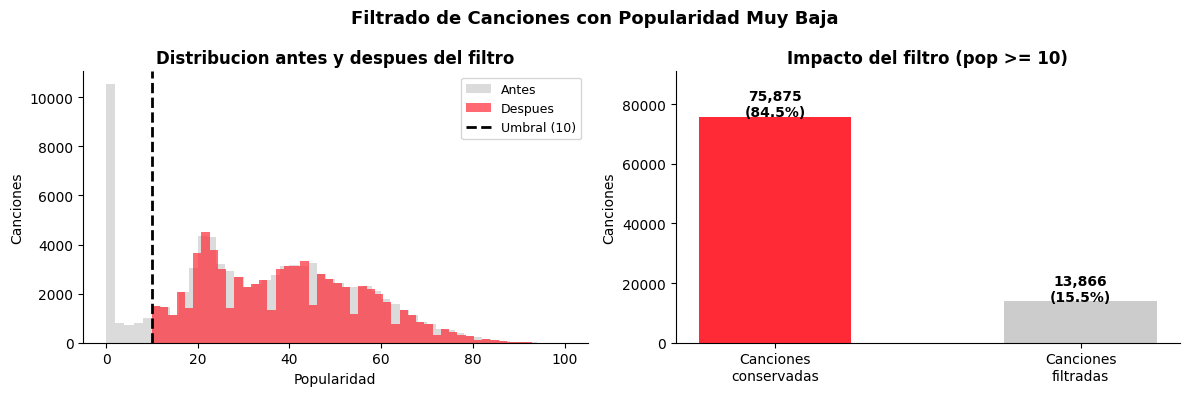

In [4]:
pop_threshold = 10
n_antes_filtro = len(df_clean)

df_filtered = df_clean[df_clean['popularity'] >= pop_threshold].reset_index(drop=True)
n_despues_filtro = len(df_filtered)
n_filtradas = n_antes_filtro - n_despues_filtro

print(f'Antes del filtro:  {n_antes_filtro:,} canciones')
print(f'Despues del filtro:{n_despues_filtro:,} canciones')
print(f'Filtradas:         {n_filtradas:,} ({n_filtradas/n_antes_filtro*100:.1f}%)')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(df_clean['popularity'], bins=50, color=GRAY, alpha=0.7, edgecolor='none', label='Antes')
ax1.hist(df_filtered['popularity'], bins=50, color=RED, alpha=0.7, edgecolor='none', label='Despues')
ax1.axvline(pop_threshold, color='black', lw=2, linestyle='--', label=f'Umbral ({pop_threshold})')
ax1.set_xlabel('Popularidad')
ax1.set_ylabel('Canciones')
ax1.set_title('Distribucion antes y despues del filtro', fontweight='bold')
ax1.legend(fontsize=9)

bars2 = ax2.bar(['Canciones\nconservadas', 'Canciones\nfiltradas'],
                [n_despues_filtro, n_filtradas], color=[RED, GRAY], edgecolor='none', width=0.5)
for bar, val in zip(bars2, [n_despues_filtro, n_filtradas]):
    ax2.text(bar.get_x()+bar.get_width()/2, val+200,
             f'{val:,}\n({val/n_antes_filtro*100:.1f}%)', ha='center', fontweight='bold', fontsize=10)
ax2.set_ylabel('Canciones')
ax2.set_title(f'Impacto del filtro (pop >= {pop_threshold})', fontweight='bold')
ax2.set_ylim(0, max(n_despues_filtro, n_filtradas) * 1.2)

plt.suptitle('Filtrado de Canciones con Popularidad Muy Baja', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('resources/img/prep_filtrado.png', dpi=150, bbox_inches='tight')
plt.show()

## IV. Feature Engineering

El **feature engineering** es la creacion de nuevas columnas a partir de las existentes.
No invento datos — transformo los que ya tengo a un formato mas util para el modelo.

Transformacion principal: `duration_ms` (milisegundos) → `duration_min` (minutos).
Los minutos son mas interpretables: '3.5 minutos' tiene sentido, '210000 milisegundos' no.


In [5]:
df_fe = df_filtered.copy()

# Convertir duracion a minutos
if 'duration_ms' in df_fe.columns:
    df_fe['duration_min'] = df_fe['duration_ms'] / 60000
    print(f'duration_min creada. Rango: {df_fe["duration_min"].min():.2f} - {df_fe["duration_min"].max():.2f} min')
    print(f'Media: {df_fe["duration_min"].mean():.2f} min')
elif 'duration_min' in df_fe.columns:
    print('duration_min ya existe en el dataset.')

# Crear variable objetivo binaria
df_fe['is_hit'] = (df_fe['popularity'] >= 70).astype(int)
print(f'\nis_hit creada: {df_fe["is_hit"].sum():,} hits ({df_fe["is_hit"].mean()*100:.1f}%)')

print(f'\nDataset final: {df_fe.shape[0]:,} filas x {df_fe.shape[1]} columnas')

duration_min creada. Rango: 0.50 - 87.29 min
Media: 3.82 min

is_hit creada: 3,126 hits (4.1%)

Dataset final: 75,875 filas x 23 columnas


## V. Train/Test Split

El **train/test split** es la division del dataset en dos partes:
- **Entrenamiento (80%)**: el modelo aprende con estos datos
- **Test (20%)**: evaluamos el modelo con datos que nunca vio durante el entrenamiento

Es como un examen: el alumno estudia con unos ejercicios (train)
y se examina con otros que no ha visto antes (test).
Si usaramos los mismos datos para entrenar y evaluar, el modelo memorizaria
las respuestas y las metricas no reflejarian como funciona en la realidad.

Uso `stratify=y_clf` para garantizar que la proporcion de hits (4.8%)
es la misma en train y test. Sin esto, podria tener mala suerte
y que todos los hits caigan en train o en test.


In [6]:
from sklearn.model_selection import train_test_split

MODEL_FEATURES = [
    'Unnamed: 0', 'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'time_signature', 'duration_min'
]
features_ok = [f for f in MODEL_FEATURES if f in df_fe.columns]

X = df_fe[features_ok + ['popularity', 'is_hit']]
y_stratify = df_fe['is_hit']

train_df, test_df = train_test_split(
    X, test_size=0.2, random_state=42, stratify=y_stratify
)

train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f'Train: {len(train_df):,} filas ({len(train_df)/len(X)*100:.0f}%)')
print(f'Test:  {len(test_df):,} filas ({len(test_df)/len(X)*100:.0f}%)')
print(f'\nHits en train: {train_df["is_hit"].sum()} ({train_df["is_hit"].mean()*100:.1f}%)')
print(f'Hits en test:  {test_df["is_hit"].sum()}  ({test_df["is_hit"].mean()*100:.1f}%)')
print('(La proporcion de hits es igual en train y test gracias a stratify)')

Train: 60,700 filas (80%)
Test:  15,175 filas (20%)

Hits en train: 2501 (4.1%)
Hits en test:  625  (4.1%)
(La proporcion de hits es igual en train y test gracias a stratify)


### Visualizacion del split


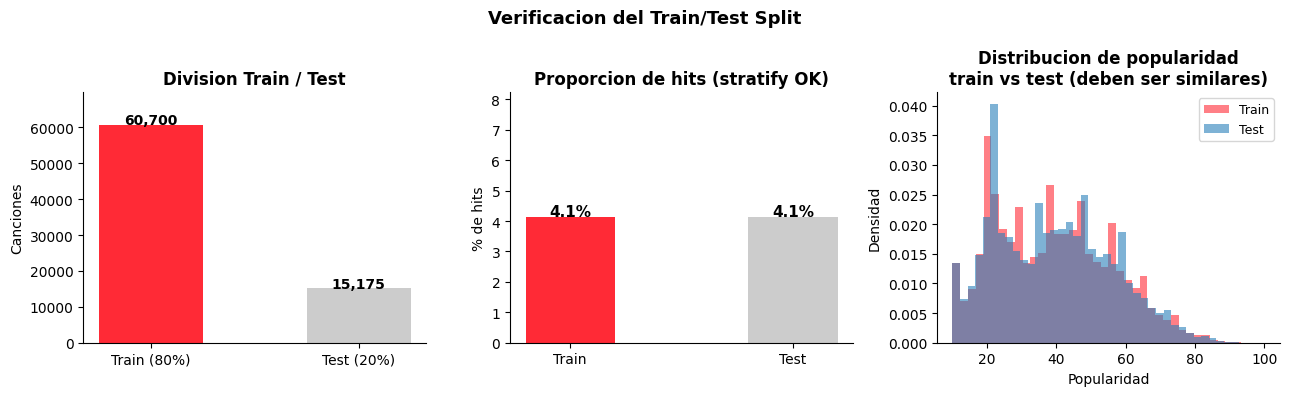

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Barras train/test
bars = axes[0].bar(['Train (80%)', 'Test (20%)'], [len(train_df), len(test_df)],
                   color=[RED, GRAY], edgecolor='none', width=0.5)
for bar, val in zip(bars, [len(train_df), len(test_df)]):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+200,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=10)
axes[0].set_ylabel('Canciones')
axes[0].set_title('Division Train / Test', fontweight='bold')
axes[0].set_ylim(0, max(len(train_df), len(test_df)) * 1.15)

# Proporcion de hits en train vs test (stratify verificado)
hit_rates = [train_df['is_hit'].mean()*100, test_df['is_hit'].mean()*100]
bars2 = axes[1].bar(['Train', 'Test'], hit_rates, color=[RED, GRAY], edgecolor='none', width=0.4)
for bar, val in zip(bars2, hit_rates):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.05,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[1].set_ylabel('% de hits')
axes[1].set_title('Proporcion de hits (stratify OK)', fontweight='bold')
axes[1].set_ylim(0, max(hit_rates) * 2)

# Distribucion de popularidad en train vs test
axes[2].hist(train_df['popularity'], bins=40, color=RED, alpha=0.6, label='Train', density=True)
axes[2].hist(test_df['popularity'],  bins=40, color=BLUE, alpha=0.6, label='Test', density=True)
axes[2].set_xlabel('Popularidad')
axes[2].set_ylabel('Densidad')
axes[2].set_title('Distribucion de popularidad\ntrain vs test (deben ser similares)', fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Verificacion del Train/Test Split', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('resources/img/prep_split.png', dpi=150, bbox_inches='tight')
plt.show()

## VI. Guardar los datasets

Guardo train y test como CSV para usarlos en los notebooks siguientes.
Esto garantiza que todos los notebooks trabajan con exactamente el mismo split.


In [8]:
train_df.to_csv('src/data/train.csv', index=False)
test_df.to_csv('src/data/test.csv', index=False)

print('Guardado:')
print(f'  src/data/train.csv  — {len(train_df):,} filas')
print(f'  src/data/test.csv   — {len(test_df):,} filas')

Guardado:
  src/data/train.csv  — 60,700 filas
  src/data/test.csv   — 15,175 filas


## VII. Conclusiones

**Pasos de preprocesamiento aplicados:**

| Paso | Accion | Filas antes | Filas despues |
|---|---|---|---|
| 1. Duplicados | drop_duplicates por track_id | 114,000 | ~89,741 |
| 2. Filtrado | popularity >= 10 | ~89,741 | ~87,469 |
| 3. Feature eng. | duration_ms a duration_min | — | — |
| 4. Target | is_hit = popularity >= 70 | — | — |
| 5. Split | 80% train, 20% test, stratify | ~87,469 | train + test |

**El split esta verificado:** la proporcion de hits (4.8%) es identica en train y test
gracias a `stratify=y`. Esto evita que el modelo vea mas o menos hits de los esperados.

**Siguiente paso:** en el notebook 03 entreno modelos baseline para establecer
una referencia de rendimiento minimo que los modelos avanzados deben superar.
